# Trained Model Comparison Table

This notebook shows one final comparison table for the three trained models using stored training metadata.
It reads artifacts/preprocessors/model_comparison_metadata.json and displays RMSE, MAE, R2, train rows, test rows, and best-model flag.

In [3]:
import json
from pathlib import Path

import pandas as pd

compare_path = None
for base_dir in [Path.cwd(), *Path.cwd().parents]:
    candidate = base_dir / 'artifacts' / 'preprocessors' / 'model_comparison_metadata.json'
    if candidate.exists():
        compare_path = candidate
        break

if compare_path is None:
    raise FileNotFoundError(
        'Missing comparison metadata. Run: python -m src.models.train_compare --target temp_max'
    )

with compare_path.open('r', encoding='utf-8') as f:
    compare_meta = json.load(f)

best_model = compare_meta.get('best_model')
rows = []
for model_key, details in compare_meta.get('models', {}).items():
    m = details.get('metrics', {})
    final_test_accuracy = m.get('final_test_accuracy')
    if final_test_accuracy is None and m.get('r2') is not None:
        final_test_accuracy = m['r2'] * 100
    rows.append({
        'model': model_key,
        'model_type': details.get('model_type', 'N/A'),
        'rmse': m.get('rmse'),
        'mae': m.get('mae'),
        'r2': m.get('r2'),
        'final_test_accuracy': final_test_accuracy,
        'train_rows': m.get('train_rows'),
        'test_rows': m.get('test_rows'),
        'is_best_model': model_key == best_model,
    })

comparison_table = pd.DataFrame(rows).sort_values('rmse').reset_index(drop=True)

display_table = comparison_table.copy()
display_table['rmse'] = display_table['rmse'].map(lambda v: f'{v:.2f}' if pd.notna(v) else v)
display_table['mae'] = display_table['mae'].map(lambda v: f'{v:.2f}' if pd.notna(v) else v)
display_table['r2'] = display_table['r2'].map(lambda v: f'{v:.2f}' if pd.notna(v) else v)
display_table['final_test_accuracy'] = display_table['final_test_accuracy'].map(lambda v: f'{v:.2f}%' if pd.notna(v) else v)

display_table

,model,model_type,rmse,mae,r2,final_test_accuracy,train_rows,test_rows,is_best_model
0,random_forest,RandomForestRegressor,1.12,0.85,0.86,86.25%,16448,4112,True
1,decision_tree,DecisionTreeRegressor,1.49,1.14,0.76,75.54%,16448,4112,False
2,linear_regression,LinearRegression,1.52,1.18,0.75,74.66%,16448,4112,False


## Comparison Visualizations
The charts below summarize model performance across RMSE, MAE, R2, and final test accuracy. Lower RMSE/MAE is better, higher R2/final test accuracy is better.

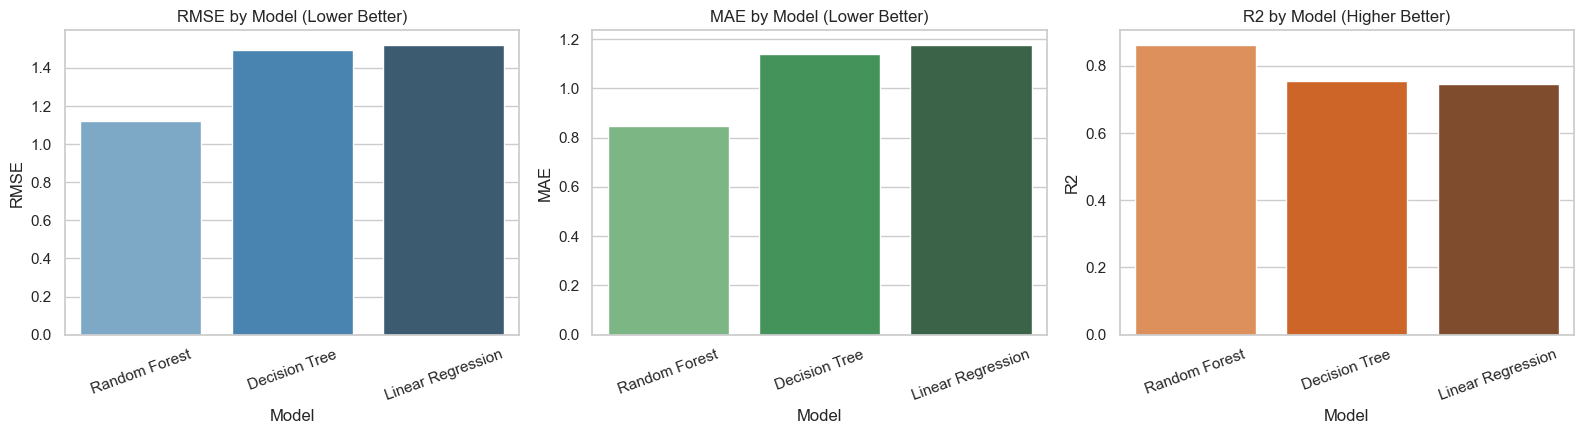

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

plot_df = comparison_table.copy()
plot_df['model'] = plot_df['model'].str.replace('_', ' ').str.title()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.barplot(data=plot_df, x='model', y='rmse', hue='model', dodge=False, legend=False, ax=axes[0], palette='Blues_d')
axes[0].set_title('RMSE by Model (Lower Better)')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=plot_df, x='model', y='mae', hue='model', dodge=False, legend=False, ax=axes[1], palette='Greens_d')
axes[1].set_title('MAE by Model (Lower Better)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=plot_df, x='model', y='r2', hue='model', dodge=False, legend=False, ax=axes[2], palette='Oranges_d')
axes[2].set_title('R2 by Model (Higher Better)')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('R2')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()